# 05 — Uncertainty plots

Full-pipeline block bootstrap intervals on p̂ and joint ability draws.
Intervals reflect parameter/data uncertainty — not match Bernoulli noise.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from tml.validation import (
    pipeline_block_bootstrap_joint_ratings,
    pipeline_block_bootstrap_p,
)
from tml.viz import plot_joint_rating_scatter, plot_probability_interval_strip


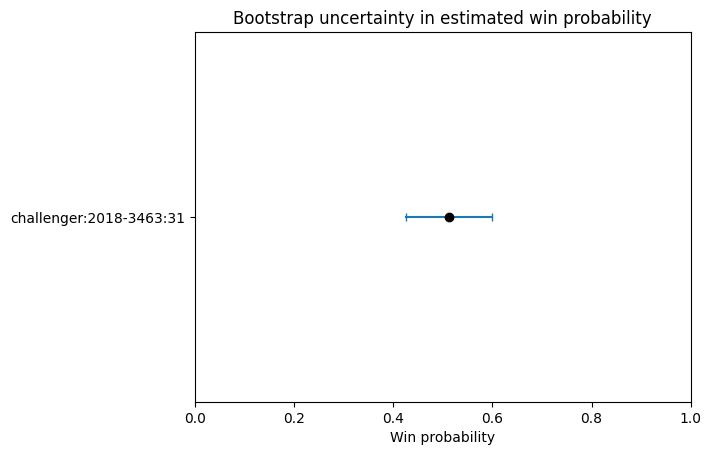

n_draws 20


In [2]:
# Small history + one target match so bootstrap finishes quickly (Elo-only draws).
matches = pd.read_parquet(Path("../data/processed/modeling.parquet"))
if "dataset_snapshot_id" not in matches.columns:
    matches["dataset_snapshot_id"] = "notebook-modeling"

matches["tourney_date"] = pd.to_datetime(matches["tourney_date"])
history = matches.loc[
    matches["tourney_date"].between("2018-01-01", "2018-06-30")
].copy()
target_id = history["match_id"].iloc[-1]

draws_by_match = pipeline_block_bootstrap_p(
    history,
    target_match_ids=[target_id],
    B=20,
    block_days=21,
    seed=0,
    include_supervised=False,
)

ax = plot_probability_interval_strip(
    {str(target_id): draws_by_match[target_id]},
    alpha=0.05,
)
plt.show()
print("n_draws", len(draws_by_match[target_id]))


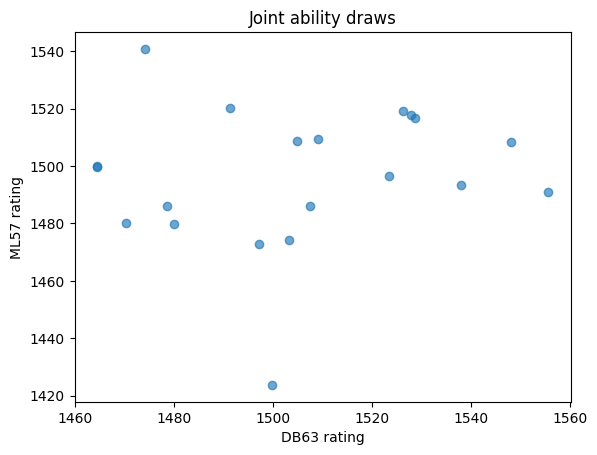

n_joint_draws 20 first (1479.9477790519638, 1479.8273232835784)


In [3]:
# Joint surface-Elo ability draws from the SAME bootstrap seed/history as above.
rating_draws = pipeline_block_bootstrap_joint_ratings(
    history,
    target_match_ids=[target_id],
    B=20,
    block_days=21,
    seed=0,
)
pairs = rating_draws[target_id]
target_row = history.loc[history["match_id"] == target_id].iloc[0]
ax = plot_joint_rating_scatter(
    pairs,
    player_a_label=str(target_row["player_a_id"]),
    player_b_label=str(target_row["player_b_id"]),
)
plt.show()
print("n_joint_draws", len(pairs), "first", pairs[0])
